# Problem Statement: Predicting Heart Failure Patient Readmissions

### 1.Domain: Healthcare Analytics
### 2.Context: 
Heart failure is a leading cause of hospitalizations worldwide, with high readmission rates placing significant burdens on healthcare systems, increasing costs, and negatively impacting patient outcomes. Identifying patients at high risk of readmission post-discharge is critical for optimizing resource allocation, tailoring post-discharge care, and improving patient quality of life.

## Objective: 
As a machine learning engineer, the goal is to develop a robust, interpretable, and scalable predictive model to accurately identify heart failure patients at risk of readmission within a specified time frame (e.g., 30 days) post-discharge. The model will leverage a comprehensive dataset encompassing patient medical history, demographics, laboratory results, hospitalization details, and treatment information to deliver actionable insights for healthcare providers.

## Challenges:
1. Data Quality: The dataset contains missing or incomplete values, requiring sophisticated imputation strategies to maintain predictive integrity without introducing bias.
2. Class Imbalance: Readmission events are less frequent than non-readmissions, necessitating techniques like oversampling (e.g., SMOTE) or cost-sensitive learning to ensure balanced model performance.
3. Feature Complexity: The interplay of diverse features—demographics (age, gender, race), comorbidities (hypertension, diabetes), lab results (creatinine, sodium levels), and hospitalization patterns (length of stay, prior admissions)—demands careful feature engineering and selection to capture relevant signals while mitigating noise.
4. Model Interpretability: Healthcare applications require models that not only predict accurately but also provide interpretable insights to guide clinical decision-making and gain stakeholder trust.
5. Generalization: The model must generalize across diverse patient populations and hospital settings, accounting for variations in care protocols and data collection practices.

## Success Criteria:
1. Achieve high predictive performance, targeting an AUC-ROC score ≥ 0.85 and balanced precision-recall for the minority class (readmitted patients).
2. Deliver interpretable insights into key drivers of readmission risk, enabling targeted interventions (e.g., enhanced follow-up care, medication adjustments).
3. Ensure computational efficiency for potential integration into hospital decision-support systems.
4. Provide a clear, actionable report summarizing model performance, feature importance, and recommendations for clinical implementation.

## Deliverables:
1. A well-documented Python-based machine learning pipeline (e.g., Jupyter Notebook) covering data preprocessing, exploratory data analysis, feature engineering, model training, and evaluation.
2. A concise report (e.g., PowerPoint) synthesizing key findings, model performance metrics, and practical recommendations for reducing readmission rates.

## Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

## Data collection

In [3]:
df = pd.read_csv('heart_failure_readmission.csv')

## Data Cleaning

In [4]:
# checking for missing values
df.isnull()

,Patient_ID,Age,Gender,Ethnicity,Length_of_Stay,Previous_Admissions,Discharge_Disposition,Pulse,Temperature,Heart_Rate,Systolic_BP,Diastolic_BP,Respiratory_Rate,BUN,Creatinine,Sodium,Hemoglobin,NT_proBNP,Ejection_Fraction,Readmission_30Days
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [5]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Patient_ID               0
Age                      0
Gender                   0
Ethnicity                0
Length_of_Stay           0
Previous_Admissions      0
Discharge_Disposition    0
Pulse                    0
Temperature              0
Heart_Rate               0
Systolic_BP              0
Diastolic_BP             0
Respiratory_Rate         0
BUN                      0
Creatinine               0
Sodium                   0
Hemoglobin               0
NT_proBNP                0
Ejection_Fraction        0
Readmission_30Days       0
dtype: int64


In [8]:
df.head()


,Patient_ID,Age,Gender,Ethnicity,Length_of_Stay,Previous_Admissions,Discharge_Disposition,Pulse,Temperature,Heart_Rate,Systolic_BP,Diastolic_BP,Respiratory_Rate,BUN,Creatinine,Sodium,Hemoglobin,NT_proBNP,Ejection_Fraction,Readmission_30Days
0,1,83,Male,Other,7,4,Rehab,119,37.1,147,160,99,27,11,0.61,127,13.1,2973,39,0
1,2,73,Female,Hispanic,10,2,Home,107,38.4,54,151,75,13,15,1.48,145,11.4,3220,56,0
2,3,59,Female,White,5,1,Expired,63,39.0,118,112,57,21,26,1.54,147,10.9,1190,50,0
3,4,87,Female,White,8,3,Expired,86,39.2,80,135,55,27,34,1.63,133,10.1,2934,29,1
4,5,52,Female,Asian,1,1,Home,117,38.5,94,145,79,16,32,2.57,146,12.8,4324,37,0


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             1000 non-null   int64  
 1   Age                    1000 non-null   int64  
 2   Gender                 1000 non-null   object 
 3   Ethnicity              1000 non-null   object 
 4   Length_of_Stay         1000 non-null   int64  
 5   Previous_Admissions    1000 non-null   int64  
 6   Discharge_Disposition  1000 non-null   object 
 7   Pulse                  1000 non-null   int64  
 8   Temperature            1000 non-null   float64
 9   Heart_Rate             1000 non-null   int64  
 10  Systolic_BP            1000 non-null   int64  
 11  Diastolic_BP           1000 non-null   int64  
 12  Respiratory_Rate       1000 non-null   int64  
 13  BUN                    1000 non-null   int64  
 14  Creatinine             1000 non-null   float64
 15  Sodiu

In [30]:
df.describe()


,Age,Length_of_Stay,Previous_Admissions,Pulse,Temperature,Heart_Rate,Systolic_BP,Diastolic_BP,Respiratory_Rate,BUN,Creatinine,Sodium,Hemoglobin,NT_proBNP,Ejection_Fraction,Readmission_30Days
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,67.000000,7.407000,1.948000,84.714000,37.715300,98.77000,135.493000,79.289000,20.563000,23.139000,1.772730,137.097000,12.53170,2552.547000,44.149000,0.287000
std,12.945562,4.086325,1.429454,20.022465,1.001438,29.20853,25.956303,17.348327,5.103732,9.381241,0.715125,7.019178,2.58824,1416.044376,14.733699,0.452588
min,45.000000,1.000000,0.000000,50.000000,36.000000,50.00000,90.000000,50.000000,12.000000,7.000000,0.500000,125.000000,8.00000,100.000000,20.000000,0.000000
25%,56.000000,4.000000,1.000000,67.000000,36.800000,74.00000,112.000000,65.000000,16.000000,15.000000,1.190000,131.000000,10.40000,1352.750000,32.000000,0.000000
50%,68.000000,7.000000,2.000000,85.000000,37.700000,97.00000,136.000000,79.000000,21.000000,23.000000,1.770000,137.000000,12.60000,2546.000000,43.500000,0.000000
75%,78.000000,11.000000,3.000000,102.000000,38.600000,125.00000,159.000000,94.250000,25.000000,31.000000,2.380000,143.000000,14.80000,3747.250000,57.000000,1.000000
max,89.000000,14.000000,4.000000,119.000000,39.500000,149.00000,179.000000,109.000000,29.000000,39.000000,3.000000,149.000000,17.00000,4997.000000,69.000000,1.000000


## Checking data properties

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 20)


In [29]:
df.head()

,Age,Gender,Ethnicity,Length_of_Stay,Previous_Admissions,Discharge_Disposition,Pulse,Temperature,Heart_Rate,Systolic_BP,Diastolic_BP,Respiratory_Rate,BUN,Creatinine,Sodium,Hemoglobin,NT_proBNP,Ejection_Fraction,Readmission_30Days
0,83,Male,Other,7,4,Rehab,119,37.1,147,160,99,27,11,0.61,127,13.1,2973,39,0
1,73,Female,Hispanic,10,2,Home,107,38.4,54,151,75,13,15,1.48,145,11.4,3220,56,0
2,59,Female,White,5,1,Expired,63,39.0,118,112,57,21,26,1.54,147,10.9,1190,50,0
3,87,Female,White,8,3,Expired,86,39.2,80,135,55,27,34,1.63,133,10.1,2934,29,1
4,52,Female,Asian,1,1,Home,117,38.5,94,145,79,16,32,2.57,146,12.8,4324,37,0



Missing Values:
 Age                      0
Gender                   0
Ethnicity                0
Length_of_Stay           0
Previous_Admissions      0
Discharge_Disposition    0
Pulse                    0
Temperature              0
Heart_Rate               0
Systolic_BP              0
Diastolic_BP             0
Respiratory_Rate         0
BUN                      0
Creatinine               0
Sodium                   0
Hemoglobin               0
NT_proBNP                0
Ejection_Fraction        0
Readmission_30Days       0
dtype: int64


In [26]:
df['Readmission_30Days'].value_counts()

Readmission_30Days
0    713
1    287
Name: count, dtype: int64

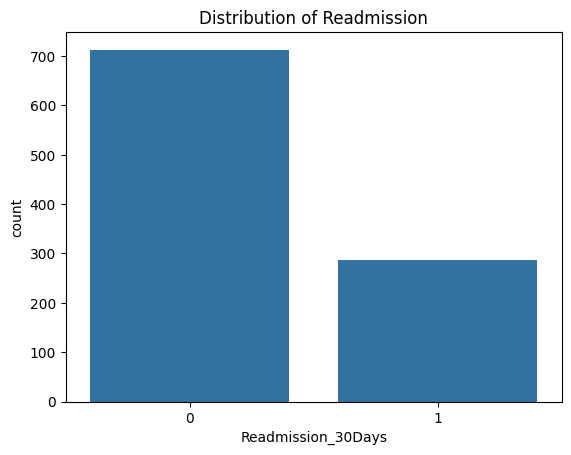

In [27]:
# Checking the distribution of the target variable
sns.countplot(x='Readmission_30Days', data=df)
plt.title('Distribution of Readmission')
plt.show()

In [ ]:
# Separate features and target variable
X = df.drop('Readmission_30Days', axis=1)
y = df['Readmission_30Days']


In [34]:
# Step 2: Identify categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

In [35]:
# Step 3: Apply Label Encoding to categorical columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le  # Store encoder for potential decoding

In [38]:
# Step 4: Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [39]:
# Step 5: Convert back to DataFrame (optional, for easier handling)
X_resampled = pd.DataFrame(X_resampled, columns=X.columns)
y_resampled = pd.Series(y_resampled, name='Readmission_30Days')

In [40]:
# Verify the resampled data
print("Original class distribution:", y.value_counts())
print("Resampled class distribution:", y_resampled.value_counts())

Original class distribution: Readmission_30Days
0    713
1    287
Name: count, dtype: int64
Resampled class distribution: Readmission_30Days
0    713
1    713
Name: count, dtype: int64


In [41]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


In [42]:
# Scaling the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [43]:
# Imputing missing values
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


In [44]:
# Training the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [45]:
# Making predictions
y_pred = rf.predict(X_test)


In [46]:
# Evaluating the model
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.80      0.74       137
           1       0.79      0.67      0.72       149

    accuracy                           0.73       286
   macro avg       0.74      0.74      0.73       286
weighted avg       0.74      0.73      0.73       286

Confusion Matrix:
 [[110  27]
 [ 49 100]]
ROC AUC Score: 0.7370303238132562


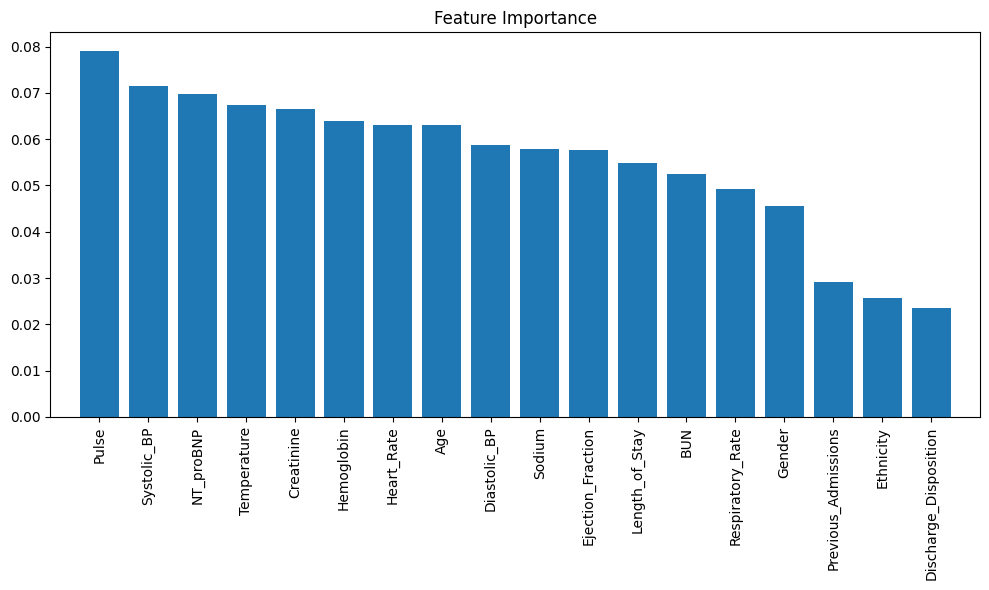

In [48]:
# Feature Importance
importances = rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]
# Plotting Feature Importance
plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()

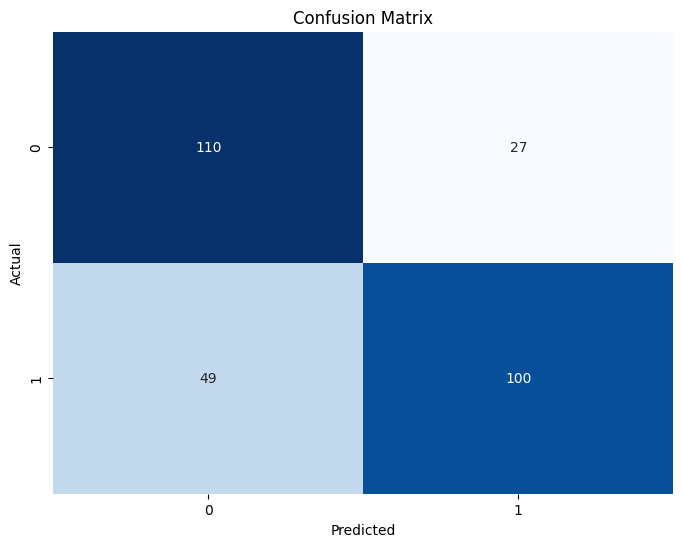

In [49]:

# Visualizing the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


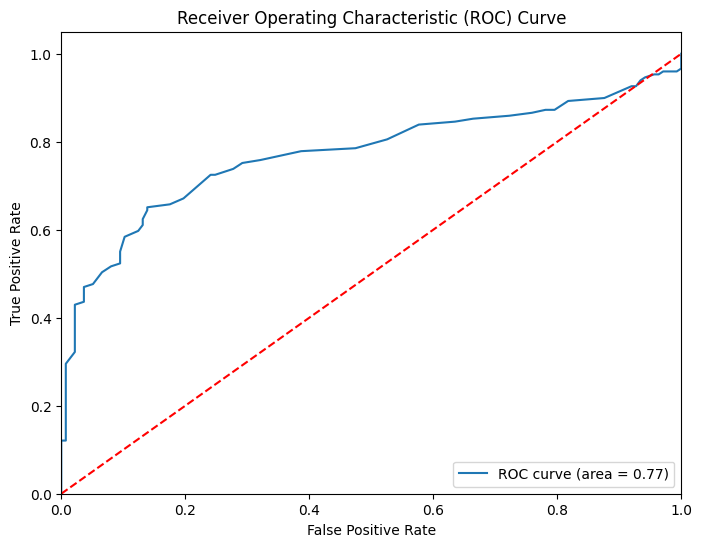

In [50]:
# Visualizing the ROC Curve
from sklearn.metrics import roc_curve, auc
y_pred_proba = rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()
 

In [51]:
# Saving the model
import joblib
joblib.dump(rf, 'heart_failure_model.pkl')


['heart_failure_model.pkl']

In [52]:
# Loading the model
loaded_model = joblib.load('heart_failure_model.pkl')


In [53]:
# Making predictions with the loaded model
sample_data = X_test[0].reshape(1, -1)
sample_prediction = loaded_model.predict(sample_data)
print("Sample Prediction:", sample_prediction)


Sample Prediction: [0]


In [54]:
# Saving the scaler
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [55]:
# Loading the scaler
loaded_scaler = joblib.load('scaler.pkl')


In [56]:
# Making predictions with the loaded scaler
sample_data_scaled = loaded_scaler.transform(sample_data)
print("Sample Data Scaled:", sample_data_scaled)
# Saving the imputer
joblib.dump(imputer, 'imputer.pkl')
# Loading the imputer
loaded_imputer = joblib.load('imputer.pkl')

Sample Data Scaled: [[ -5.29222936   1.40841777  -1.7641859   -1.86810542  -1.75777856
   -1.58253622  -4.47924823 -38.08991977  -3.440793    -5.44811133
   -4.75710565  -3.9917482   -2.38499682  -2.26674393 -19.94062964
   -5.2697197   -1.8435003   -3.21470039]]
